# Chem Echo 🎶

## Introduction

Sonification, the translation of information to nonspeech sound [1], of abstract chemical concepts and properties as a multisensory approach is a useful tool to develop a deeper, more intuitive understanding of these ideas [2]. Beyond the sighted audience, sonification of chemical data makes chemistry accessible to visually impaired persons, which is a true challenge, as chemical information ranging from structures of molecules to their IR spectra is almost exclusively available in graphical form [3]. Sonification of molecules can also contribute to the improvement of AI-aided drug discovery and design by capturing dynamic molecular properties, which addresses a major limitation of AI in chemistry: the absence of mechanistic understanding [4]. 

This work aims to create an auditory support for the representation of molecules based on their infrared (IR) spectrum. ChemEcho is a Python package that uses the NIST Standard Reference Database Number 69 [5] to create an audio that translates the available IR spectrum and includes information on molecular weight as well as the number of carbon atoms in the molecule. The generated audio starts by a series of cymbal sounds that indicate the number of carbon atoms in the molecule, the audio-IR spectrum then follows. Time corresponds to the wavenumber. Time markers are included every 100 cm $^{-1}$ (snare drum) and every 500 cm $^{-1}$ (kick drum). The tempo varies with the molecular weight of the molecule: based on kinetic theory, a lighter molecule moves faster while a heavier molecule moves slower. The presence of a functional group signalled by a peak in the IR spectrum is marked by a specific sound, depending on the identity of the functional group. Our package includes an interactive application that visually displays the IR spectrum, the molecular structure and includes the audio, ready to be played.




## Project construction and material

### Necessary packages and extentions

Our translation of IR spectrum into music was based on several scientific papers, that proposed to link certain audio characteristics to spectroscopy theory. Before explaining the logic behind it, few practical researches were necessary to find all the tools to IR spectrum conversion. 

First, an adequate database was needed to provide enough IR spectrum data. The National Institute of Standards and Technology (NIST) provided a convenient one, with more 16.000 spectrum available. Additionnaly, the choice of this database was motivated by the existence of an API, installable with the package `nistchempy` that can realize the parsing of wanted data. 

Typical IR spectrum data is available in .jdx file format, which makes it necessary to find a way of reading these types of file. The package `jcamp` was used in this project to realize this purpose and to extract data into two lists, one for x-value, the wavenumbers, and the other for y-value, the transmittance. These lists were then convenient to plot the IR spectrum with matplotlib and to generate a MIDI file. 

About the latter, another package of music generation was needed. The decision was made to go with the package musicpy, whose documentation is very rich and allowed great flexibility and creativity. An additional module (daw) was necessary to ... (Zoé). 

Finally, the aim of the project was also to provide a great interface that makes the music generation easy and intuitive. To do so, a streamlit app was developed, using the `streamlit` package, and the display of MIDI file directly in the app was made possible by using HTML encoding. 

Additionnaly, PubChem database was used to display images of molecules. The API was used for SMILES research, based on CAS, name or empirical formula. `rdkit` and `py3Dmol` packages are then useful to translate into 2D and 3D representations respectively. 

### Translation logic

Firstly, the choice of parameters used for the literal translation was made. The need was to express the transmittance and wavenumber variations as music parameters, while keeping a pleasant sound result. The first approach for wavenumbers was based on the formula that links the frequency of a wave to its wavenumber. Then, the frequency of the note played would have been directly determined by this principle. Then, a natural approach for the transmittance [%] would have been to dictate the intensity of the note played. The greater the absorption, the louder the sound. However, the first results were not conclusive in the sense that it was difficult to detect peaks this way. 

$f=c\cdot \sigma$

Where f is the frequency [$s^{-1}$], c the light celerity in vacuum (equal to $3.00\cdot 10^{10}$ cm $\cdot$ s $^{-1}$) and $\sigma $ the wavenumber [$cm^{-1}$]. 

Hence, the translation evolved in adapting the frequency of the note as a function of transmittance: for high absorption, the frequency is high and then modelizing the wavenumbers through regular beats as "graduation" through the reading of the reading from left to right. 

On this base, two versions of "musification" were developed for two different uses: 
- Version 1 (basic): provides the literal translation of the IR spectrum, with fixed tempo in order to compare easily two different spectra. 
- Version 2 (functional groups): provides detection of different functional groups, number of carbone and adapted tempo

In the Version 2, to meet the spectroscopy theory, the tempo of the music was directly adapted and proportionaly linked to the square root of molecular weight of the molecule. Indeed, lighter molecule will vibrate more rapidly, while heavier one will be harder to move. This can be modelized by the following relation: 

$v \propto \frac{1}{\sqrt{M}} $

where $v$ is the velocity and $M$ the molecular weight

The tempo is then calculated using a linear interpolation of the square root of molecular weight between two values that give a minimal and a maximal tempo (the min value has a molecular of 16 g $\cdot$ mol $^{-1}$ and a bpm of 60, while the max value has a molecular weight of 500 g $\cdot$ mol $^{-1}$ and a $bpm$ of 120)

bpm $=$ bpm $_{min}+($ bpm $_{max}-$ bpm $_{min}) \frac{1/\sqrt{M}-k_{min}}{k_{max}-k_{min}}$

where $k_i=\frac{1}{\sqrt{M_i}}$ and bpm $_i$ is the tempo of i

Functional groups are also detected based on wavenumbers' reference values for absorption. The data used for the detection are given in the following table. Each functional group is then signified by a single note at the maximum absorption by a different instrument. 
Finally, an extra beats sequence is added at the beginning of the music as a "signature" to indicate the number of carbones in the molecule. 

...




## Results and main functions

### Spectrum extraction

The first step of the processus is to extract raw data from the NIST database with the package function `extract_spectrum_data`. To do so, `nistchempy` package functions were used in two ways: the first to create a nist.compound.NistCompound for each requested molecule. This object contains several interesting parameters such as molecule name, molecular weight and spectrum .jdx can be then requested with adapted function `.get_ir_spectrum()`. Through the tests realized, several observations were made. The first was the lack of uniformity in units. Indeed, the "classic" units in spectroscopy are wavenumbers and transmittance of light. However, IR spectrum can also be displayed with the wavelength of the incident light instead of its wavenumber and the absorbance or the reflectance can be used instead of the transmittance. The choice in this project was to uniform the units to have comparable spectrum. Hence, wavelength was transformed in wavenumber with Eq. () and absorbance in transmittance with Eq. (). Unfortunately, the reflectance could not be easily transformed in transmittance, leading to necessary error handling in our function. Other eventual units were also set aside, such as molar absorptivity or dispersion index. 

$\sigma =\frac{1}{\lambda}$ 

$T=10^{-A}$

Recursive calls of the function were also added in the case of molecule which possesses several spectrum available, and whose first spectrum does not have compatible units. 

### Visual support

Three visual supports are displayed in the streamlit for users to compare and to see that the audio results match with molecule properties and actual IR spectrum. By combining data contained in `nist.compound.NistCompound` and research in the PubChem API, the skeletal formula and the 3D representation can be found. For the "classic" IR spectrum, data was plotted with the `ir_graph` function. 

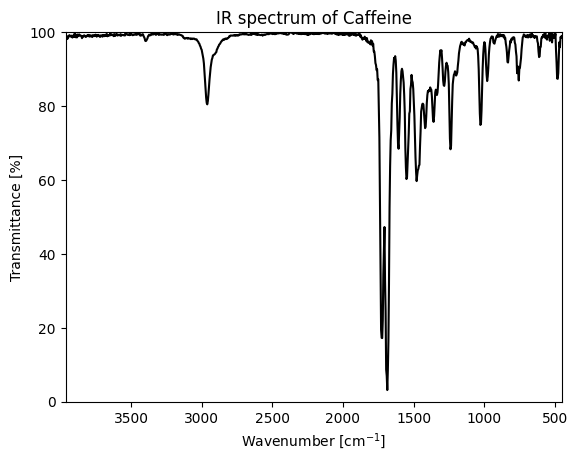

In [9]:
import nistchempy as nist
import sys
from pathlib import Path
import matplotlib.pyplot as plt

sys.path.append(str(Path.cwd().parent / "src" / "chemecho"))

from get_spectrum import extract_spectrum_data, ir_graph

compound = nist.get_compound("58-08-2")
data = extract_spectrum_data(compound)

fig, ax = ir_graph(data, compound.name)
plt.show()

For the skeletal formula, the function used is `draw_molecule`:

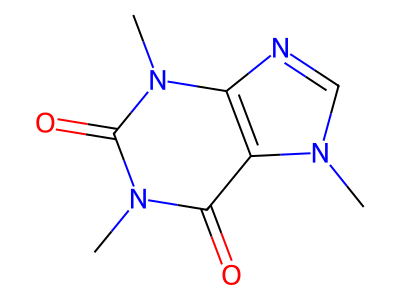

In [ ]:
from utils import draw_molecule, molecule_3d_html, resolve_molecule, nist_compound_from

info = resolve_molecule("58-08-2")
smiles = info['smiles']
draw_molecule(smiles)

And for the 3D representation, the corresponding function is `molecule_3D_html`:

In [14]:
import py3Dmol

molecule_3d_html(smiles)

'<div id="3dmolviewer_17795631280800962"  style="position: relative; width: 100%; height: 380px;">\n        <p id="3dmolwarning_17795631280800962" style="background-color:#ffcccc;color:black">3Dmol.js failed to load for some reason.  Please check your browser console for error messages.<br></p>\n        </div>\n<script>\n\nvar loadScriptAsync = function(uri){\n  return new Promise((resolve, reject) => {\n    //this is to ignore the existence of requirejs amd\n    var savedexports, savedmodule;\n    if (typeof exports !== \'undefined\') savedexports = exports;\n    else exports = {}\n    if (typeof module !== \'undefined\') savedmodule = module;\n    else module = {}\n\n    var tag = document.createElement(\'script\');\n    tag.src = uri;\n    tag.async = true;\n    tag.onload = () => {\n        exports = savedexports;\n        module = savedmodule;\n        resolve();\n    };\n  var firstScriptTag = document.getElementsByTagName(\'script\')[0];\n  firstScriptTag.parentNode.insertBefore

### Music generation



The two main functions that create the MIDI files for the Version 1 and Version 2 are respectively `molecular_music` and `molecular_music_fg`. However, there are also other functions that are crucial for a pleasing result. The first that concerns the two versions is `peak_detection` that allows a smoothing of the noise present for high transmittances and that could cause additional frequency changes that are not relevant. 

![Capture d'écran 2026-05-23 225729.png](<attachment:Capture d'écran 2026-05-23 225729.png>)
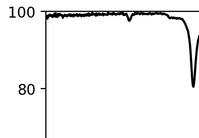

Then, the functions `detect_functional_groups` and `find_absorption_peaks` allow the detection of functional groups in the spectrum. The assignement of each instrument is provided in these functions. (Yunhee)

In [12]:
from IPython.display import HTML, display
import base64
import os
from musification import molecular_music

try:
    midi_path = molecular_music(data, compound)

    with open(midi_path, "rb") as f:
        midi_bytes = f.read()
finally:
    if os.path.exists(midi_path):
        os.remove(midi_path)
            
midi_b64 = base64.b64encode(midi_bytes).decode()

display(HTML(f"""
    <script src="https://cdn.jsdelivr.net/npm/tone@14/build/Tone.js"></script>
    <script src="https://cdn.jsdelivr.net/npm/@magenta/music@1.23.1/es6/core.js"></script>
    <script src="https://cdn.jsdelivr.net/npm/html-midi-player@1.5.0"></script>
    <midi-player
        src="data:audio/midi;base64,{midi_b64}"
        sound-font
        style="width:100%;">
    </midi-player>
"""))

<class 'nistchempy.compound.NistCompound'>
878


### Streamlit app

The purpose of the Streamlit app is to make easy and fluid all the processus - from data extraction to music generation. By a simple request, CAS, name, SMILES or empirical formula of the molecule, the skeletal formula, the 3D visualisation, the plotted and the musical IR spectrum are displayed, in the first or the second version as wanted.  The user also have the possibility to download documents of interest: IR spectrum plot and music in .csv and .mid format respectively. 

The app provides an integrated MIDI player, allowing to directly listen the results provided by the `molecular_music_fg` without using an external file player. 

![Capture d'écran 2026-05-23 231054.png](<attachment:Capture d'écran 2026-05-23 231054.png>)

For the Version 1, a slider is displayed to let the user choose the apropriate tempo. 

Additionnaly, the list of functional groups is also available at the end of the page, completing the IR spectrum analysis. 

![Capture d'écran 2026-05-23 200423.png](<attachment:Capture d'écran 2026-05-23 200423.png>)
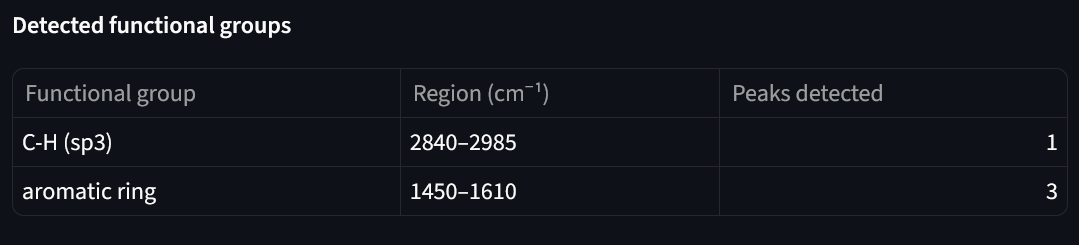
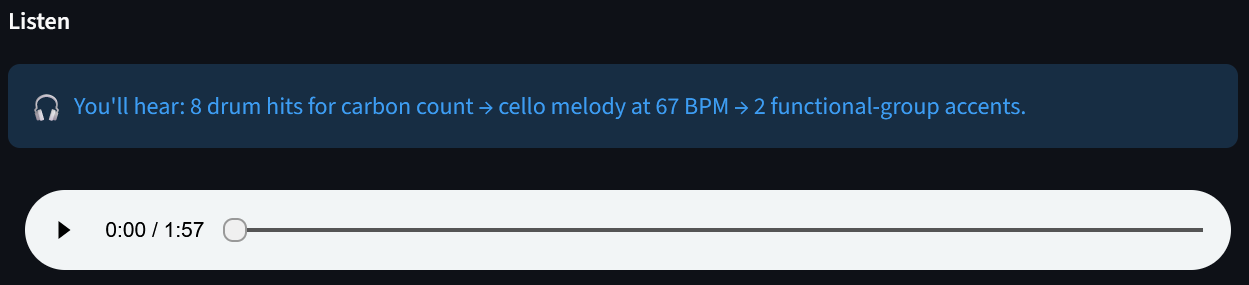

## References

1. Dubus, G.; Bresin, R. A Systematic Review of Mapping Strategies for the Sonification of Physical Quantities. PLoS ONE 2013, 8 (12), e82491. https://doi.org/10.1371/journal.pone.0082491  

2. Kim, S. H.; Heller, E. J. Musical Molecules: Sonifying the IR Spectra and Modeling Intramolecular Vibrational Energy Redistribution of Small Molecules; arXiv 2026. https://doi.org/10.48550/arXiv.2601.02652  

3. Pereira, F.; Ponte-e-Sousa, J. C.; Fartaria, R. P. S.; Bonifácio, V. D. B.; Mata, P.; Aires-de-Sousa, J.; Lobo, A. M. Sonified Infrared Spectra and Their Interpretation by Blind and Visually Impaired Students. J. Chem. Educ. 2013, 90 (8), 1028–1031. https://doi.org/10.1021/ed4000124  

4. Zhou, C. J.; Zhou, E. R. Molecular Sonification: A Multi-Modal Approach for Enhanced AI in Drug Discovery. Med. Chem. Res. 2026, 35, 778–783. https://doi.org/10.1007/s00044-026-03549-y

5. Linstrom, P. J.; Mallard, W. G., Eds. NIST Chemistry WebBook, NIST Standard Reference Database Number 69; National Institute of Standards and Technology: Gaithersburg, MD, 1997. https://doi.org/10.18434/T4D303